# Tutorial 3: MERFISH Human Developmental Cortex

In this tutorial, we implemented NovAST using the [human MERFISH developmental cortex dataset](https://www.nature.com/articles/s41586-025-09010-1), with the original data available at the [Zenodo](https://zenodo.org/records/14422018). We converted the data into AnnData (`.h5ad`) format and stored in the `demo_data/Tutorial3_MERFISH_development_cortex` directory in this [GitHub repository](https://github.com/YMa-lab/NovAST/). We use slice `UMB5900-BA40a` as reference and slice `UMB5900-BA40b` as target, with both from the gestational week 34. 

## 1. Import NovAST Functions
After installing the package, import the required functions from NovAST for subsequent use.

In [1]:
from NovAST import run_NovAST, NovAST_plot, NovAST_evaluation
import warnings
warnings.filterwarnings("ignore")

/oscar/home/yzhu194/stellar_py/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Preparation
NovAST requires both **reference** and **target** datasets in **AnnData (.h5ad)** format. Specify the dataset paths below for subsequent loading.

In [ ]:
reference_path="gw34_UMB5900-BA40a.h5ad"
target_path="gw34_UMB5900-BA40b.h5ad"

Next, we set NovAST to **evaluation mode**, since ground-truth cell type annotations are available for both the reference and target datasets and we aim to quantitatively evaluate model performance. Accordingly, we specify the columns that store the cell type labels for each dataset. A unique aspect of this dataset is that we remove cell type labels at a higher level of the hierarchy, such that an entire group of related cell types sharing the same root is excluded simultaneously.

In [ ]:
training_mode = "evaluation"

# Column name in the reference and target AnnData that stores cell-type annotations
celltype_name_reference="H2_annotation"
celltype_name_target="H2_annotation"

# Unique to this dataset, we set the cell type labels used for removal at one level higher in hierarchy than the lables for transfer 
celltype_name_reference_select="H1_annotation"
celltype_name_target_select="H1_annotation"

## 3. Required Arguments
The following parameters **must** be specified when running NovAST:

In [ ]:
# Name of the output directory where results will be saved
name="demo_evaluation_removefurthest"

# A user-defined dataset identifier used for organizing output files
dataset = "merfish_development_cortex"
 
# Saving directory
savedir = "./"

All remaining hyperparameters are defined in the file **`default_config.yaml`**.  
Users may override any of them directly when calling `run_NovAST()` if customization is needed.
For instance, `rounds` is set to 10 by default. Reducing this value can substantially decrease runtime by performing fewer training rounds, at the cost of a slight performance drop due to the ensemble strategy.

## 4. Run NovAST
In the manuscript, we applied the pseudo-novel strategy by manually removing one cell type from the reference dataset and treating it as ground-truth novel cells in the target dataset. Accordingly, all arguments remain the same except that `remove_celltype` is set to `True` to enable the pseudo-novel mode, and `remove_celltype_type` is set to one of `['most', 'least', 'closest', 'furthest']`, corresponding to the **Most Abundant**, **Least Abundant**, **Most Mixed**, and **Most Separated** scenarios, respectively.

Here, we illustrate the **Most Separated** setting.

In [3]:
args = run_NovAST(
    training_mode=training_mode,
    reference_path=reference_path,
    target_path=target_path,
    celltype_name_reference=celltype_name_reference,
    celltype_name_target=celltype_name_target,
    celltype_name_reference_select=celltype_name_reference_select,
    celltype_name_target_select=celltype_name_target_select,  
    remove_celltype=True,
    remove_celltype_type="furthest",
    name=name,
    dataset=dataset,
    spot_size=5
)

Random seed set as 42
The saving directory set to ./demo_evaluation_removefurthest


H1_annotation
Number of overlapped genes: 300
Datasets have been preprocessed!


2026-02-06 21:10:22.029856: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-06 21:10:26.801857: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Removed from TRAIN: ['EN-ET']
──────────────────────────────────────────
Starting training for seed 1...
Random seed set as 2
Part I training started! Round 1


Training: 100%|██████████| 50/50 [05:55<00:00,  7.11s/it]


...

Part I training done
--- 458.17384338378906 seconds ---
Step2 started!
Cells more than 100k, use the faster version!
UMAPing takes 373.48120164871216 seconds
Labelspreading takes 158.87709546089172 seconds
Part II training done
--- 618.4473536014557 seconds ---
──────────────────────────────────────────
Starting training for seed 9...
Random seed set as 10
Part I training started! Round 9


Training: 100%|██████████| 50/50 [05:56<00:00,  7.13s/it]


Part I training done
--- 456.6168577671051 seconds ---
Step2 started!
Cells more than 100k, use the faster version!
UMAPing takes 373.230917930603 seconds
Labelspreading takes 160.25218629837036 seconds
Part II training done
--- 618.4037342071533 seconds ---
──────────────────────────────────────────
Starting training for seed 10...
Random seed set as 11
Part I training started! Round 10


Training: 100%|██████████| 50/50 [05:52<00:00,  7.05s/it]


Part I training done
--- 452.82636308670044 seconds ---
Step2 started!
Cells more than 100k, use the faster version!
UMAPing takes 373.5510380268097 seconds
Labelspreading takes 158.58914732933044 seconds
Part II training done
--- 617.4199283123016 seconds ---
Loading seed 1
Loading seed 2
Loading seed 3
Loading seed 4
Loading seed 5
Loading seed 6
Loading seed 7
Loading seed 8
Loading seed 9
Loading seed 10
Saving voted seed 1
Saving voted seed 2
Saving voted seed 3
Saving voted seed 4
Saving voted seed 5
Saving voted seed 6
Saving voted seed 7
Saving voted seed 8
Saving voted seed 9
Saving voted seed 10


For each training round, the pipeline saves all outputs to the specified directory, with each random seed assigned its own subfolder. This includes the trained model, the Stage-1 loss values, and a final result file named **`adata_unlabeled_final.h5ad`**, which stores the latent embeddings in **`.obsm['X_latent']`** and the final predicted labels in **`.obs['voted_final_prediction']`**.

## 5. Visualize the output
Running the following line of code will generate UMAP visualizations as well as spatial plots of the predicted cell types and their associated confidence scores, and save them to each individual seed’s output directory. Evaluation metrics will also be computed and saved. Below, we show one representative seed.

Evaluation mode detected. Processing 10 seeds...

──────────────────────────────────────────
Starting evaluation for seed 1...
Random seed set as 2
Generating UMAP plot with ground truth...
UMAP plot saved.
Generating spatial plot (region key = None)...
Spatial plot saved.

──────────────────────────────────────────
Starting evaluation for seed 2...
Random seed set as 3
Generating UMAP plot with ground truth...
UMAP plot saved.
Generating spatial plot (region key = None)...
Spatial plot saved.

──────────────────────────────────────────
Starting evaluation for seed 3...
Random seed set as 4
Generating UMAP plot with ground truth...
UMAP plot saved.
Generating spatial plot (region key = None)...
Spatial plot saved.

──────────────────────────────────────────
Starting evaluation for seed 4...
Random seed set as 5
Generating UMAP plot with ground truth...
UMAP plot saved.
Generating spatial plot (region key = None)...
Spatial plot saved.

──────────────────────────────────────────
Startin

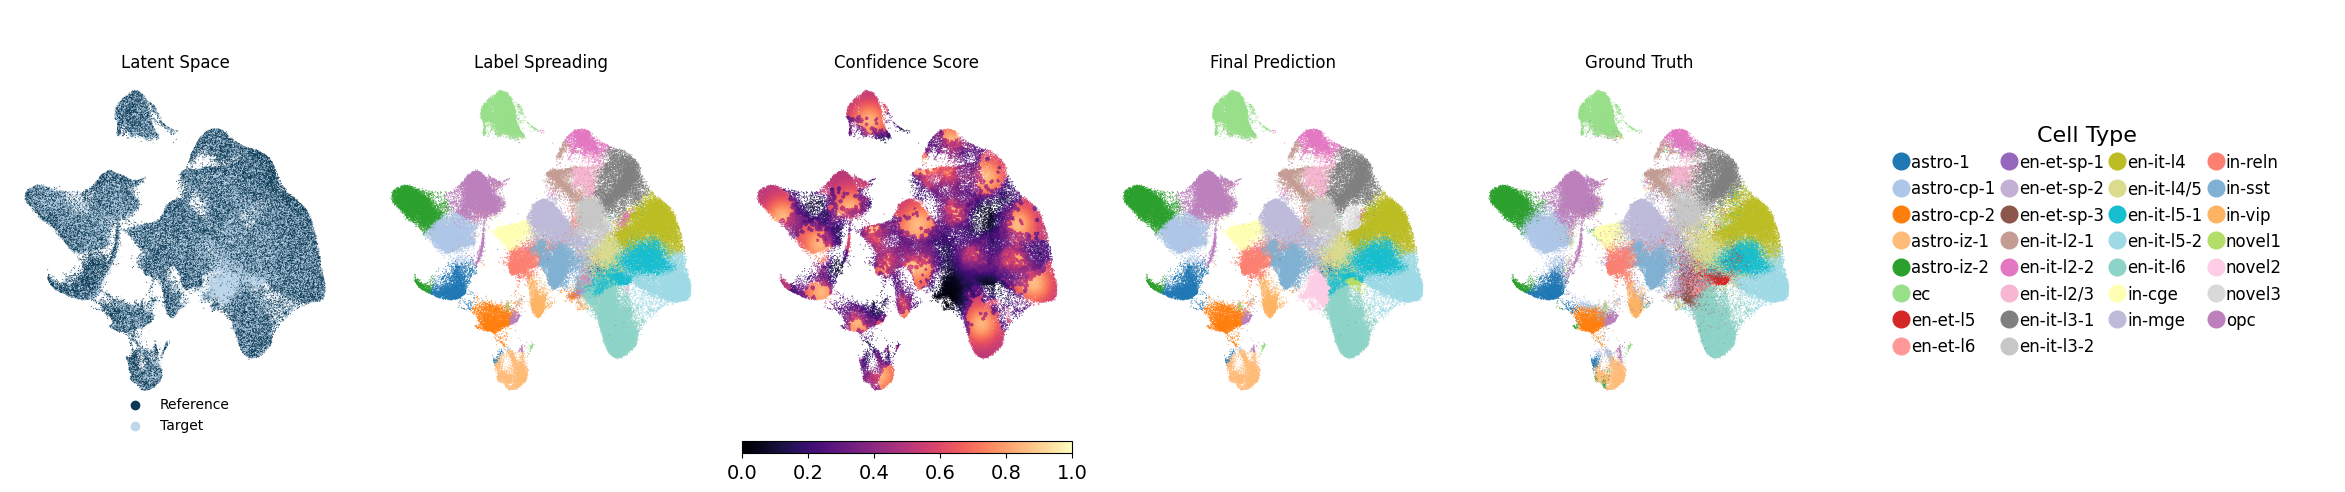

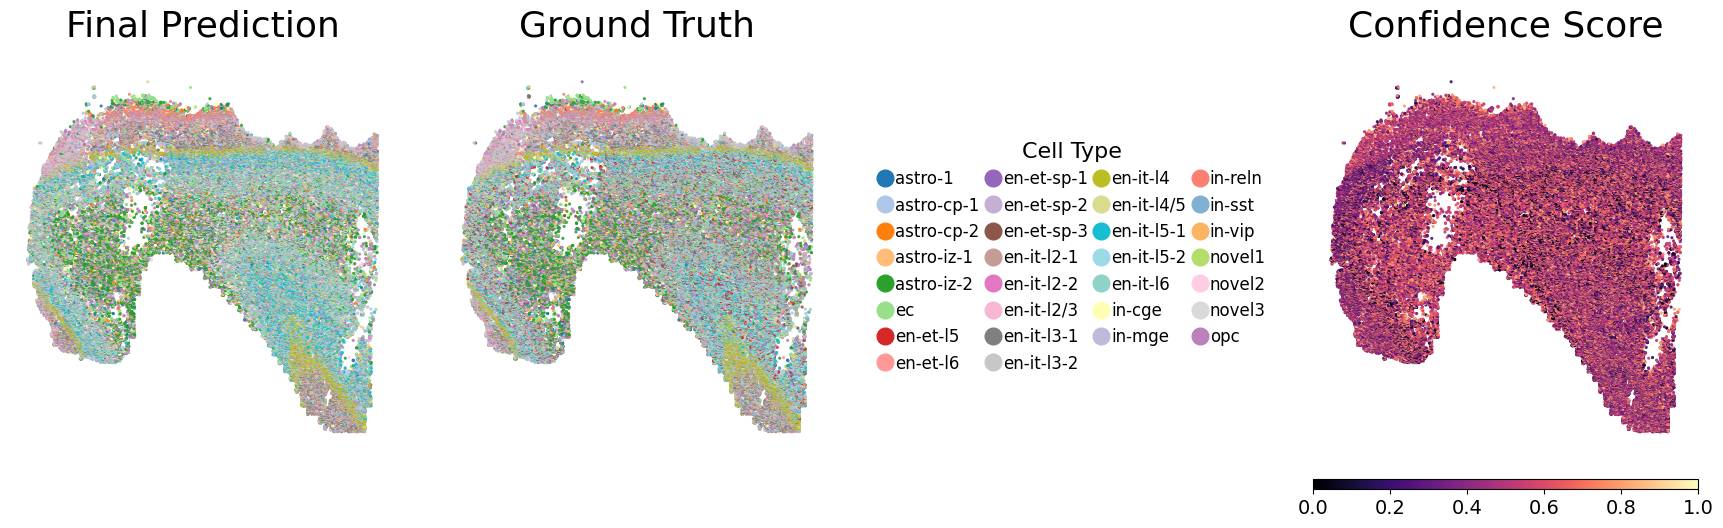

In [5]:
metrics_df = NovAST_evaluation(args)